# User Classification Model for Cluster Assignment

This notebook creates a classification model to assign new users to existing clusters based on their behavior patterns.

## Models Implemented:
- XGBoost Classifier
- LightGBM Classifier  
- Neural Network (MLP)
- Ensemble Model (Voting)

## Features Used:
- total_events: Total number of user interactions
- total_views: Number of product views
- total_purchases: Number of purchases
- avg_time_between_events: Average time between user actions
- total_spent: Total amount spent
- avg_basket: Average basket size
- conversion_rate: Purchase conversion rate
- purchase_ratio: Purchase to view ratio
- days_since_last_event: User activity recency
- is_active: Active user flag (days_since_last_event < 30)

In [1]:
# Install required packages
#%pip install xgboost lightgbm tensorflow scikit-learn pandas numpy matplotlib seaborn duckdb pathlib tqdm

## 1. Load Data and Environment Setup

In [2]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Advanced models
import xgboost as xgb
import lightgbm as lgb

# Set random seeds for reproducibility
RANDOM_STATE = 42
LIMIT = 10000

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

## 2. Data Preparation and Feature Engineering

In [4]:
# Load or create user segments data
try:
    # Try to load from user_segments_kmeans table
    df = con.execute(f"SELECT * FROM user_segments_kmeans").fetchdf()
    print(f"Loaded {len(df)} users from user_segments_kmeans")
except:
    try:
        # Try user_segments table
        df = con.execute("SELECT * FROM user_segments").fetchdf()
        print(f"Loaded {len(df)} users from user_segments")
    except:
        print("No user segments table found")

# Feature engineering
df["is_active"] = (df["days_since_last_event"] < 30).astype(int)

# Add additional derived features
df['events_per_day'] = df['total_events'] / np.maximum(df['days_since_last_event'], 1)
df['spend_per_event'] = df['total_spent'] / np.maximum(df['total_events'], 1)
df['view_to_purchase_ratio'] = df['total_views'] / np.maximum(df['total_purchases'], 1)

print(f"Final dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Loaded 4905 users from user_segments_kmeans
Final dataset shape: (4905, 17)

Columns:
['user_id', 'total_events', 'total_views', 'total_purchases', 'avg_time_between_events', 'total_spent', 'avg_basket', 'last_event_time', 'conversion_rate', 'purchase_ratio', 'days_since_last_event', 'category_embedding', 'segment', 'is_active', 'events_per_day', 'spend_per_event', 'view_to_purchase_ratio']


Segment distribution:
segment
0    1415
1    1725
2     335
3    1176
4       6
5     248
Name: count, dtype: int64


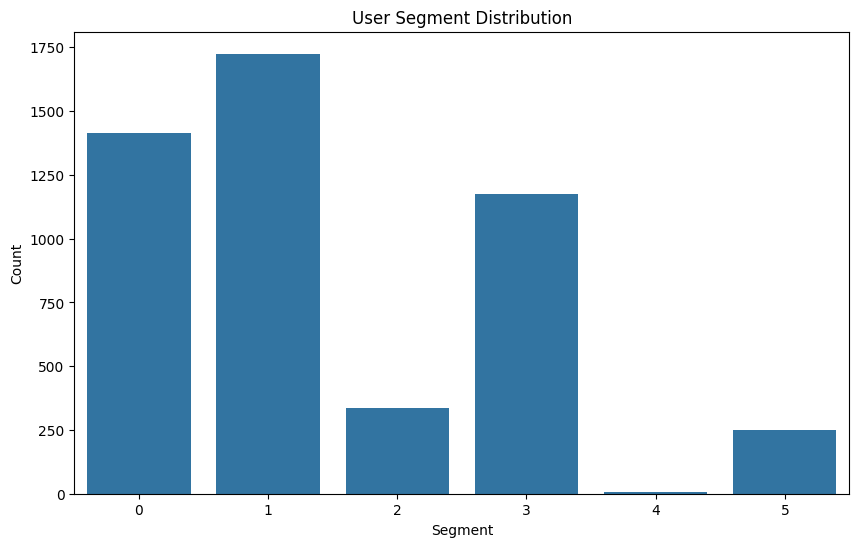

In [5]:
# Check segment distribution
print("Segment distribution:")
segment_counts = df['segment'].value_counts().sort_index()
print(segment_counts)

# Visualize segment distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='segment')
plt.title('User Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

In [6]:
# Prepare features and target
feature_columns = [
    'total_events', 'total_views', 'total_purchases', 
    'avg_time_between_events', 'total_spent', 'avg_basket',
    'conversion_rate', 'purchase_ratio', 'days_since_last_event',
    'is_active', 'events_per_day', 'spend_per_event', 'view_to_purchase_ratio'
]

# Remove any columns that don't exist
available_features = [col for col in feature_columns if col in df.columns]
print(f"Available features: {available_features}")

# Separate features and target
X = df[available_features].copy()
y = df['segment'].copy()

# Handle missing values
X = X.fillna(X.median())
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(y.unique())}")

Available features: ['total_events', 'total_views', 'total_purchases', 'avg_time_between_events', 'total_spent', 'avg_basket', 'conversion_rate', 'purchase_ratio', 'days_since_last_event', 'is_active', 'events_per_day', 'spend_per_event', 'view_to_purchase_ratio']
Features shape: (4905, 13)
Target shape: (4905,)
Number of classes: 6


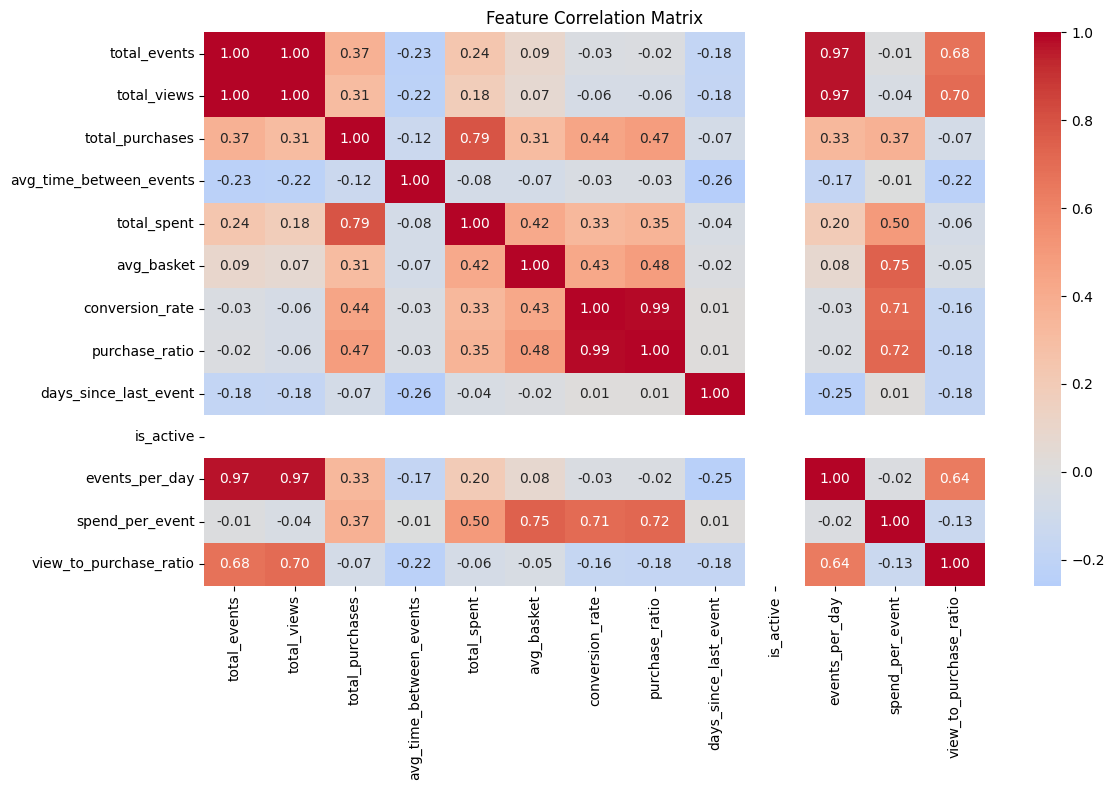

In [7]:
# Feature correlation analysis
plt.figure(figsize=(12, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training segments distribution: {np.bincount(y_train)}")
print(f"Test segments distribution: {np.bincount(y_test)}")

Training set: (3924, 13)
Test set: (981, 13)
Training segments distribution: [1132 1380  268  941    5  198]
Test segments distribution: [283 345  67 235   1  50]


## 3. Model Training and Evaluation

In [9]:
# Create preprocessing pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed")
print(f"Scaled training data shape: {X_train_scaled.shape}")

Data preprocessing completed
Scaled training data shape: (3924, 13)


In [10]:
# Initialize models
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        objective="reg:linear"
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200
    )
}

print("Models initialized:")
for name in models.keys():
    print(f"- {name}")

Models initialized:
- XGBoost
- LightGBM
- Random Forest


In [11]:
# Train and evaluate each model
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="neg_mean_squared_error")
    
    results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    trained_models[name] = model
    
    print(f"{name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Training XGBoost...
XGBoost - Accuracy: 0.8593, F1: 0.8602, CV: -0.4513 (+/- 0.0292)

Training LightGBM...
LightGBM - Accuracy: 0.8746, F1: 0.8752, CV: -0.5573 (+/- 0.2526)

Training Random Forest...
Random Forest - Accuracy: 0.8685, F1: 0.8685, CV: -0.4602 (+/- 0.0456)



Model Performance Comparison:
               accuracy  f1_score   cv_mean    cv_std
LightGBM       0.874618  0.875220 -0.557302  0.252578
Random Forest  0.868502  0.868452 -0.460243  0.045584
XGBoost        0.859327  0.860239 -0.451318  0.029239


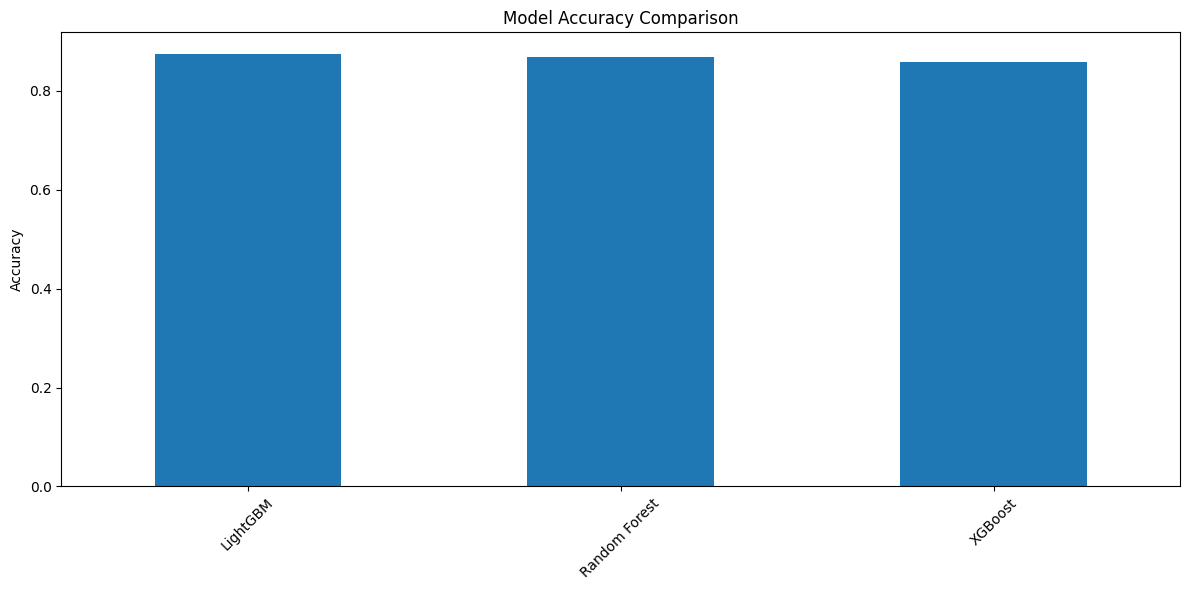

In [12]:
# Display results comparison
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df.sort_values('accuracy', ascending=False))

# Visualize results
plt.figure(figsize=(12, 6))
results_df['accuracy'].sort_values(ascending=False).plot(kind='bar')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Detailed classification report for LightGBM:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       283
           1       0.86      0.87      0.87       345
           2       1.00      0.94      0.97        67
           3       0.94      0.93      0.93       235
           4       1.00      1.00      1.00         1
           5       0.98      0.92      0.95        50

    accuracy                           0.87       981
   macro avg       0.93      0.91      0.92       981
weighted avg       0.88      0.87      0.88       981



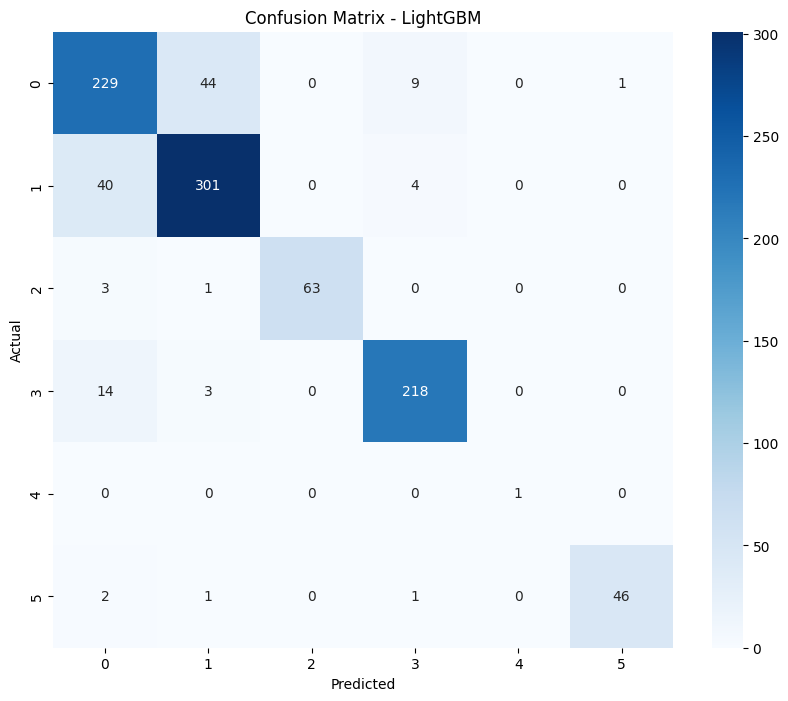

In [13]:
# Detailed classification report for best model
best_model_name = results_df['accuracy'].idxmax()
best_model = trained_models[best_model_name]

print(f"\nDetailed classification report for {best_model_name}:")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4. Feature Importance Analysis

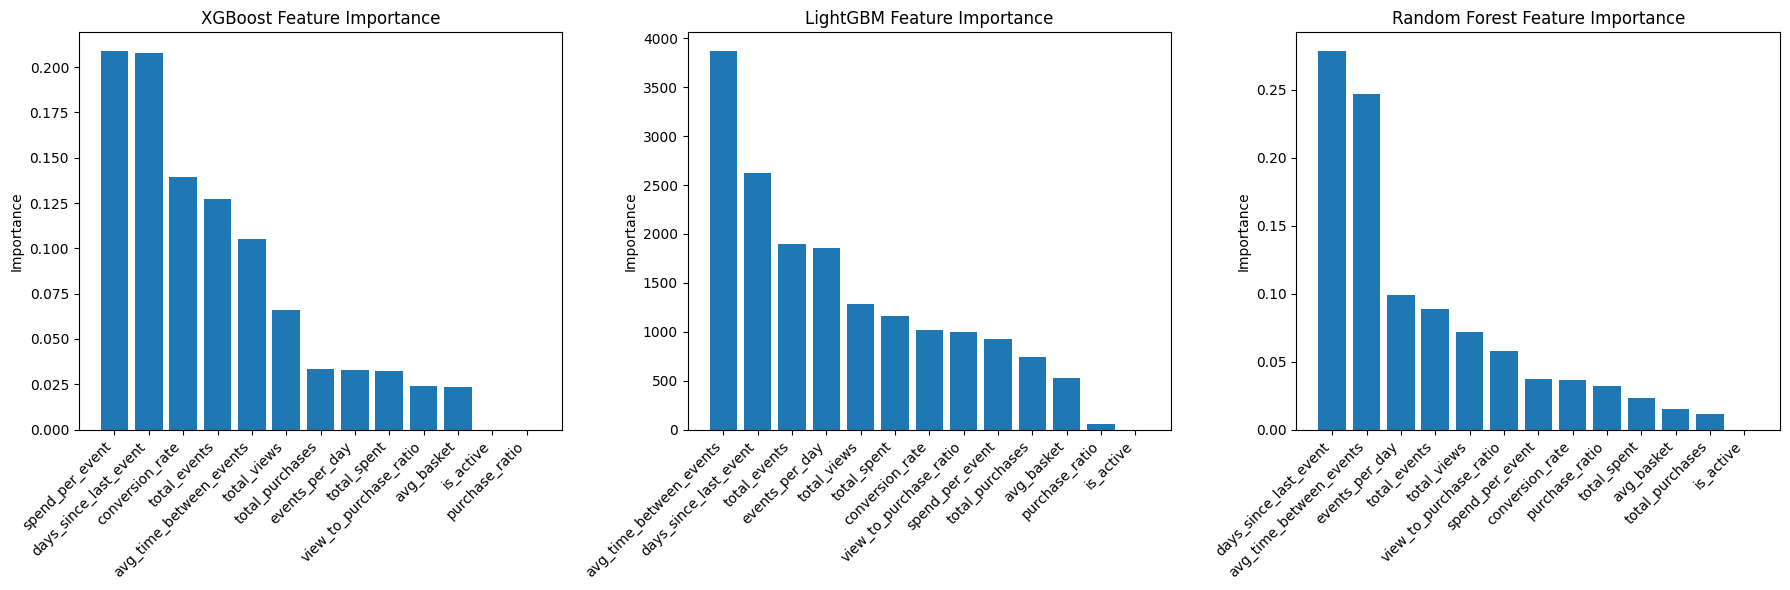

In [14]:
# Feature importance for tree-based models
tree_models = ['XGBoost', 'LightGBM', 'Random Forest']

fig, axes = plt.subplots(1, len(tree_models), figsize=(18, 6))
if len(tree_models) == 1:
    axes = [axes]

for i, model_name in enumerate(tree_models):
    if model_name in trained_models:
        model = trained_models[model_name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            axes[i].bar(range(len(importances)), importances[indices])
            axes[i].set_title(f'{model_name} Feature Importance')
            axes[i].set_xticks(range(len(importances)))
            axes[i].set_xticklabels([available_features[i] for i in indices], rotation=45, ha='right')
            axes[i].set_ylabel('Importance')

plt.tight_layout()
plt.show()

## 5. Model Saving and Inference Pipeline

In [15]:
import joblib
import json
from datetime import datetime

# Create models directory if it doesn't exist
models_dir = Path('saved_models')
models_dir.mkdir(exist_ok=True)

# Save the best model and preprocessing components
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save best model
best_model_path = models_dir / f'best_classifier_{best_model_name.lower().replace(" ", "_")}_{timestamp}.joblib'
joblib.dump(best_model, best_model_path)
print(f"Best model saved to: {best_model_path}")

# Save scaler
scaler_path = models_dir / f'scaler_{timestamp}.joblib'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Save feature names and model metadata
metadata = {
    'model_name': best_model_name,
    'features': available_features,
    'timestamp': timestamp,
    'accuracy': results[best_model_name]['accuracy'],
    'f1_score': results[best_model_name]['f1_score'],
    'classes': sorted(y.unique().tolist())
}

metadata_path = models_dir / f'metadata_{timestamp}.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {metadata_path}")

# Save all models for comparison
for name, model in trained_models.items():
    model_path = models_dir / f'{name.lower().replace(" ", "_")}_{timestamp}.joblib'
    joblib.dump(model, model_path)
    print(f"{name} model saved to: {model_path}")

Best model saved to: saved_models/best_classifier_lightgbm_20260209_002532.joblib
Scaler saved to: saved_models/scaler_20260209_002532.joblib
Metadata saved to: saved_models/metadata_20260209_002532.json
XGBoost model saved to: saved_models/xgboost_20260209_002532.joblib
LightGBM model saved to: saved_models/lightgbm_20260209_002532.joblib
Random Forest model saved to: saved_models/random_forest_20260209_002532.joblib


In [16]:
def classify_new_user(user_data: Dict, model_path: Path, scaler_path: Path, metadata_path: Path) -> Dict:
    """
    Classify a new user into existing segments
    
    Args:
        user_data: Dictionary containing user features
        model_path: Path to saved model
        scaler_path: Path to saved scaler
        metadata_path: Path to metadata file
    
    Returns:
        Dictionary with classification results
    """
    # Load model and preprocessing components
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    # Prepare features
    features = []
    for feature_name in metadata['features']:
        if feature_name in user_data:
            features.append(user_data[feature_name])
        else:
            features.append(0)  # Default value for missing features
    
    # Convert to numpy array and reshape
    features_array = np.array(features).reshape(1, -1)
    
    # Scale features
    features_scaled = scaler.transform(features_array)
    
    # Make prediction
    predicted_segment = model.predict(features_scaled)[0]
    prediction_proba = model.predict_proba(features_scaled)[0]
    
    # Create results dictionary
    results = {
        'predicted_segment': int(predicted_segment),
        'confidence': float(np.max(prediction_proba)),
        'all_probabilities': {
            str(cls): float(prob) for cls, prob in zip(metadata['classes'], prediction_proba)
        },
        'model_name': metadata['model_name'],
        'model_accuracy': metadata['accuracy']
    }
    
    return results

print("Classification function defined successfully!")

Classification function defined successfully!


In [17]:
# Test the classification function with sample data
test_user = {
    'total_events': 45,
    'total_views': 38,
    'total_purchases': 3,
    'avg_time_between_events': 85000,
    'total_spent': 245.50,
    'avg_basket': 81.83,
    'conversion_rate': 0.067,
    'purchase_ratio': 0.079,
    'days_since_last_event': 15,
    'is_active': 1,
    'events_per_day': 3.0,
    'spend_per_event': 5.46,
    'view_to_purchase_ratio': 12.67
}

# Classify the test user
result = classify_new_user(
    test_user, 
    best_model_path, 
    scaler_path, 
    metadata_path
)

print("Classification Results:")
print(json.dumps(result, indent=2))

print(f"\nTest user classified as segment {result['predicted_segment']} with {result['confidence']:.2%} confidence")

Classification Results:
{
  "predicted_segment": 0,
  "confidence": 0.9635194613852741,
  "all_probabilities": {
    "0": 0.9635194613852741,
    "1": 0.036465401325128904,
    "2": 2.6379539331656907e-06,
    "3": 1.0132961770612599e-05,
    "4": 5.218739098061061e-08,
    "5": 2.314186502267432e-06
  },
  "model_name": "LightGBM",
  "model_accuracy": 0.8746177370030581
}

Test user classified as segment 0 with 96.35% confidence


In [18]:
# Batch classification function
def classify_multiple_users(users_data: List[Dict], model_path: Path, scaler_path: Path, metadata_path: Path) -> List[Dict]:
    """
    Classify multiple users at once
    
    Args:
        users_data: List of dictionaries containing user features
        model_path: Path to saved model
        scaler_path: Path to saved scaler
        metadata_path: Path to metadata file
    
    Returns:
        List of classification results
    """
    # Load model and preprocessing components
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    results = []
    
    for user_data in users_data:
        # Prepare features
        features = []
        for feature_name in metadata['features']:
            if feature_name in user_data:
                features.append(user_data[feature_name])
            else:
                features.append(0)  # Default value for missing features
        
        # Convert to numpy array and reshape
        features_array = np.array(features).reshape(1, -1)
        
        # Scale features
        features_scaled = scaler.transform(features_array)
        
        # Make prediction
        predicted_segment = model.predict(features_scaled)[0]
        prediction_proba = model.predict_proba(features_scaled)[0]
        
        # Create results dictionary
        result = {
            'predicted_segment': int(predicted_segment),
            'confidence': float(np.max(prediction_proba)),
            'model_name': metadata['model_name'],
            'model_accuracy': metadata['accuracy']
        }
        
        results.append(result)
    
    return results

print("Batch classification function defined successfully!")

Batch classification function defined successfully!


## 6. Model Monitoring and Validation

In [19]:
# Model validation on test set
print("Final Model Validation:")
print(f"Model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"Test F1-Score: {results[best_model_name]['f1_score']:.4f}")

# Per-class metrics
from sklearn.metrics import precision_score, recall_score

precision_per_class = precision_score(y_test, y_pred_best, average=None)
recall_per_class = recall_score(y_test, y_pred_best, average=None)

print("\nPer-class Performance:")
for i, segment in enumerate(sorted(y.unique())):
    segment_count = (y_test == segment).sum()
    print(f"Segment {segment}: Precision={precision_per_class[i]:.3f}, Recall={recall_per_class[i]:.3f}, Count={segment_count}")

Final Model Validation:
Model: LightGBM
Test Accuracy: 0.8746
Test F1-Score: 0.8752

Per-class Performance:
Segment 0: Precision=0.795, Recall=0.809, Count=283
Segment 1: Precision=0.860, Recall=0.872, Count=345
Segment 2: Precision=1.000, Recall=0.940, Count=67
Segment 3: Precision=0.940, Recall=0.928, Count=235
Segment 4: Precision=1.000, Recall=1.000, Count=1
Segment 5: Precision=0.979, Recall=0.920, Count=50


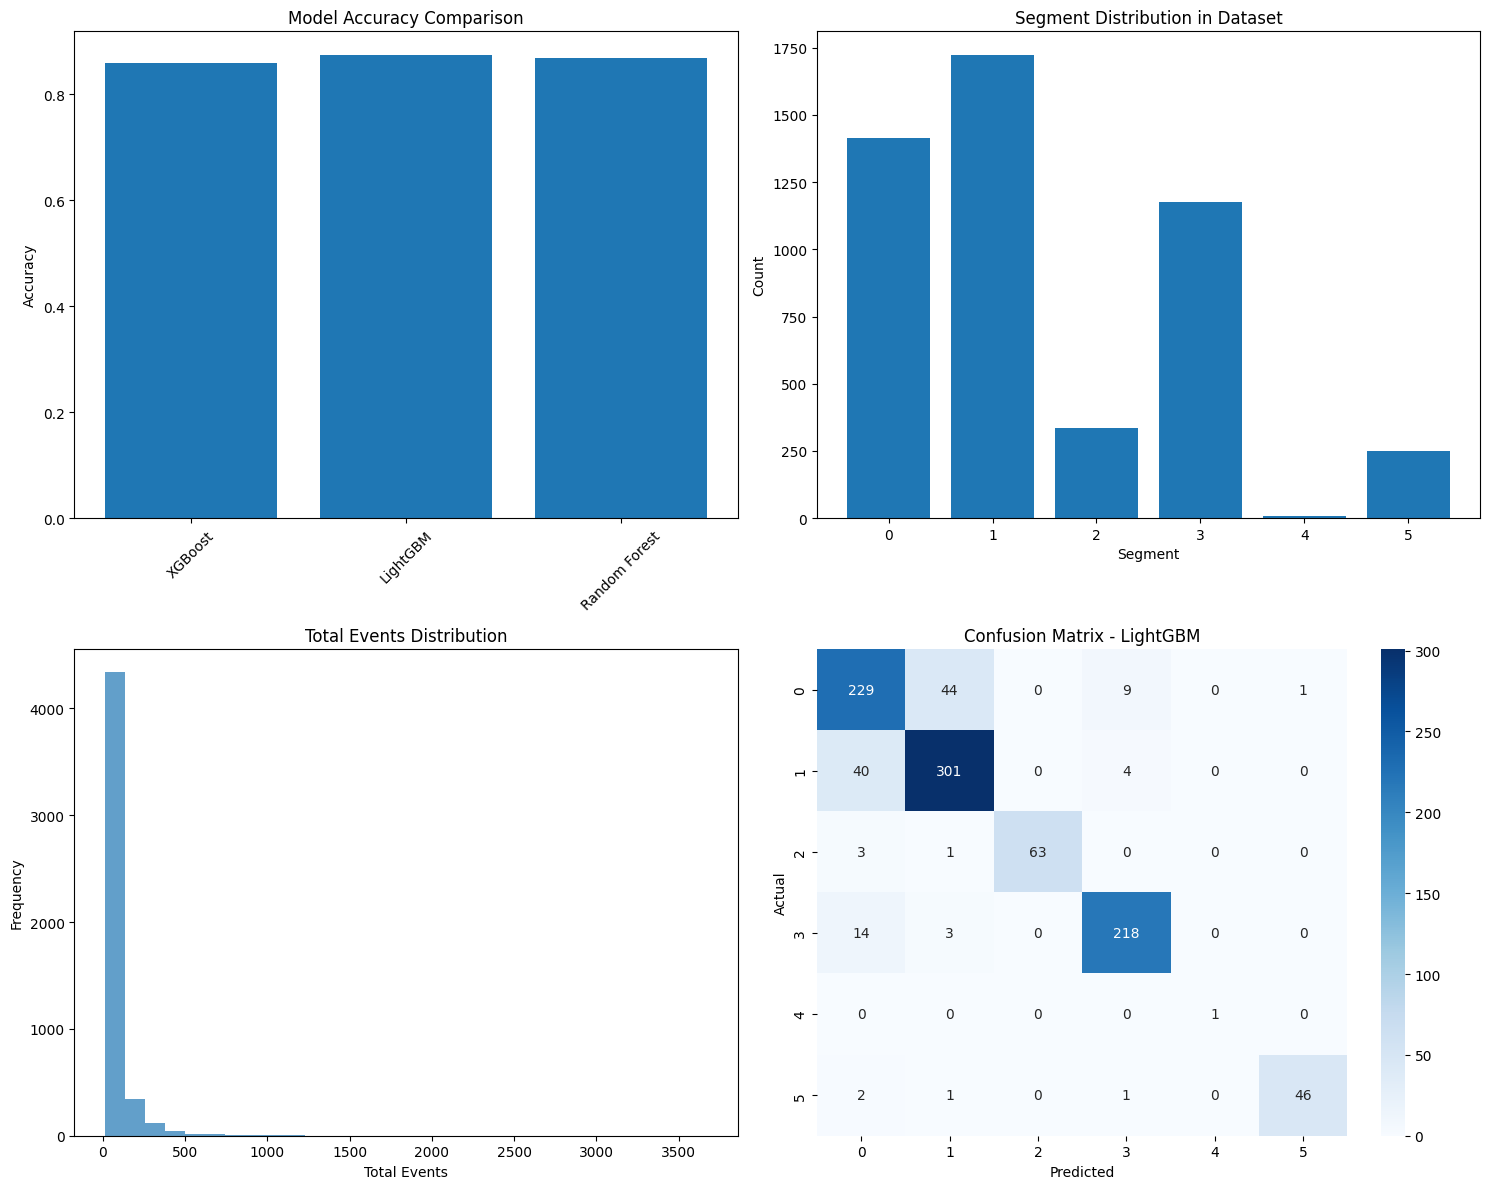

In [20]:
# Create a simple monitoring dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy comparison
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
axes[0, 0].bar(model_names, accuracies)
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Segment distribution
segment_dist = df['segment'].value_counts().sort_index()
axes[0, 1].bar(segment_dist.index, segment_dist.values)
axes[0, 1].set_title('Segment Distribution in Dataset')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Count')

# 3. Feature distribution (example: total_events)
axes[1, 0].hist(df['total_events'], bins=30, alpha=0.7)
axes[1, 0].set_title('Total Events Distribution')
axes[1, 0].set_xlabel('Total Events')
axes[1, 0].set_ylabel('Frequency')

# 4. Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Summary and Next Steps

In [21]:
print("=" * 60)
print("USER CLASSIFICATION MODEL - SUMMARY")
print("=" * 60)
print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f"Number of Segments: {len(y.unique())}")
print(f"Features Used: {len(available_features)}")

print(f"\nFeatures:")
for i, feature in enumerate(available_features):
    print(f"  {i+1}. {feature}")

print(f"\nModel Files Saved:")
print(f"  - Best Model: {best_model_path}")
print(f"  - Scaler: {scaler_path}")
print(f"  - Metadata: {metadata_path}")

print("\n" + "=" * 60)
print("USAGE INSTRUCTIONS")
print("=" * 60)
print("\nTo classify new users, use the classify_new_user function:")
print("""
result = classify_new_user(
    user_data_dict,
    model_path,
    scaler_path,
    metadata_path
)
""")

print("\nFor batch classification, use classify_multiple_users function.")
print("\nModel is ready for production deployment!")

USER CLASSIFICATION MODEL - SUMMARY

Best Model: LightGBM
Accuracy: 0.8746
F1-Score: 0.8752
Number of Segments: 6
Features Used: 13

Features:
  1. total_events
  2. total_views
  3. total_purchases
  4. avg_time_between_events
  5. total_spent
  6. avg_basket
  7. conversion_rate
  8. purchase_ratio
  9. days_since_last_event
  10. is_active
  11. events_per_day
  12. spend_per_event
  13. view_to_purchase_ratio

Model Files Saved:
  - Best Model: saved_models/best_classifier_lightgbm_20260209_002532.joblib
  - Scaler: saved_models/scaler_20260209_002532.joblib
  - Metadata: saved_models/metadata_20260209_002532.json

USAGE INSTRUCTIONS

To classify new users, use the classify_new_user function:

result = classify_new_user(
    user_data_dict,
    model_path,
    scaler_path,
    metadata_path
)


For batch classification, use classify_multiple_users function.

Model is ready for production deployment!


In [22]:
# Close database connection
con.close()
print("\nDatabase connection closed.")
print("Classification model training completed successfully!")


Database connection closed.
Classification model training completed successfully!
